# Planners-7-OR-Tools - Programmation par Contraintes

**Navigation** : [Index](../../README.md) | [<< Domaines](../02-Classical/Planners-6-Domains.ipynb) | [Temporel >>](Planners-8-Temporal.ipynb)

## OR-Tools pour la Planification

Ce notebook introduit **Google OR-Tools**, une suite d'optimisation open-source qui offre une approche complementaire a la planification PDDL classique. Plutot que de chercher dans un espace d'etats, OR-Tools utilise la **programmation par contraintes (CP-SAT)** pour resoudre des problemes de planification.

### Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. **Comprendre** le paradigme de programmation par contraintes (CP)
2. **Utiliser** OR-Tools CP-SAT pour des problemes de planification
3. **Modeliser** des problemes d'ordonnancement (job-shop scheduling)
4. **Resoudre** des problemes de tournees de vehicules (VRP)
5. **Comparer** CP vs PDDL : forces et faiblesses de chaque approche

### Prerequis
- Avoir suivi [Planners-2-PDDL-Basics](../01-Foundation/Planners-2-PDDL-Basics.ipynb)
- Connaissance de base en Python
- Notions d'optimisation combinatoire

### Duree estimee : 45 minutes

---

## 1. Introduction a la Programmation par Contraintes

La **Programmation par Contraintes (CP)** est un paradigme different de la planification classique basee sur PDDL.

### 1.1 CP vs PDDL : Deux paradigmes

| Aspect | PDDL (Planification) | CP (Contraintes) |
|--------|---------------------|------------------|
| **Modele** | Etats + Actions | Variables + Contraintes |
| **Resolution** | Recherche dans l'espace d'etats | Propagation + Recherche |
| **Objectif** | Sequence d'actions | Affectation de variables |
| **Optimalite** | Plan le plus court | Minimisation/Maximisation |
| **Problemes types** | Blocks World, Logistics | Scheduling, Routing, Sudoku |

### 1.2 Quand utiliser CP vs PDDL ?

**Utiliser PDDL quand** :
- Le probleme implique des actions avec preconditions/effets
- L'ordre des actions est crucial
- On cherche un plan (sequence d'actions)

**Utiliser CP quand** :
- Le probleme est essentiellement combinatoire
- On optimise une fonction objectif (temps, cout, ressources)
- Les contraintes sont plus naturelles que les actions
- Le probleme est statique (pas de "sequence d'actions")

### 1.3 Elements du modele CP

Un probleme CP se definit par :

1. **Variables de decision** : $x_1, x_2, \ldots, x_n$ avec domaines $D_1, D_2, \ldots, D_n$
2. **Contraintes** : Relations entre variables ($x_1 + x_2 \leq 10$, $x_1 \neq x_2$)
3. **Fonction objectif** : Minimiser ou maximiser $f(x_1, \ldots, x_n)$

**Exemple** : Scheduling
- Variables : $start_i$ = temps de debut de la tache $i$
- Contraintes : $start_i + duration_i \leq start_j$ (precedence)
- Objectif : Minimiser $\max_i(start_i + duration_i)$ (makespan)

---

## 2. OR-Tools CP-SAT : Les bases

**CP-SAT** est le solveur de contraintes le plus performant d'OR-Tools. Il combine :
- Propagation de contraintes
- Recherche arborescente
- Resolution SAT moderne (CDCL)
- Optimisation par recherche lineaire

In [1]:
# Imports et verification de l'environnement
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional

# OR-Tools
try:
    from ortools.sat.python import cp_model
    from ortools.sat.python.cp_model import CpSolver, CpModel
    print("OR-Tools CP-SAT disponible")
    ORTOOLS_OK = True
except ImportError:
    print("ERREUR: OR-Tools non installe")
    print("Solution: pip install ortools")
    ORTOOLS_OK = False

# Configuration matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

import warnings
warnings.filterwarnings('ignore')

OR-Tools CP-SAT disponible


### 2.1 Premier exemple : Probleme simple

Resolvons un probleme simple : assigner 3 taches a 2 machines de facon a minimiser le temps total.

In [2]:
if ORTOOLS_OK:
    # Creation du modele
    model = cp_model.CpModel()
    
    # Donnees du probleme
    num_tasks = 3
    num_machines = 2
    durations = [3, 2, 4]  # Duree de chaque tache
    horizon = sum(durations)  # Borne superieure du temps total
    
    # Variables de decision
    # start[i] = temps de debut de la tache i
    # end[i] = temps de fin de la tache i
    # machine[i] = machine assignee a la tache i
    start = [model.NewIntVar(0, horizon, f'start_{i}') for i in range(num_tasks)]
    end = [model.NewIntVar(0, horizon, f'end_{i}') for i in range(num_tasks)]
    machine = [model.NewIntVar(0, num_machines - 1, f'machine_{i}') for i in range(num_tasks)]
    
    # Contraintes : duree des taches
    for i in range(num_tasks):
        model.Add(end[i] == start[i] + durations[i])
    
    # Contraintes : pas de chevauchement sur une meme machine
    for i in range(num_tasks):
        for j in range(i + 1, num_tasks):
            # Si tache i et j sur la meme machine, alors pas de chevauchement
            # Utilisation d'une variable boolenne pour la condition
            same_machine = model.NewBoolVar(f'same_{i}_{j}')
            model.Add(machine[i] == machine[j]).OnlyEnforceIf(same_machine)
            model.Add(machine[i] != machine[j]).OnlyEnforceIf(same_machine.Not())
            
            # i avant j OU j avant i (si meme machine)
            i_before_j = model.NewBoolVar(f'{i}_before_{j}')
            model.Add(end[i] <= start[j]).OnlyEnforceIf(i_before_j)
            model.Add(end[j] <= start[i]).OnlyEnforceIf(i_before_j.Not())
            
            # Au moins une des conditions doit etre vraie si meme machine
            model.AddBoolOr([same_machine.Not(), i_before_j, i_before_j.Not()])
    
    # Objectif : minimiser le makespan (temps de fin maximum)
    makespan = model.NewIntVar(0, horizon, 'makespan')
    model.AddMaxEquality(makespan, end)
    model.Minimize(makespan)
    
    # Resolution
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 10.0
    status = solver.Solve(model)
    
    # Affichage des resultats
    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        print(f"Statut: {'OPTIMAL' if status == cp_model.OPTIMAL else 'FEASIBLE'}")
        print(f"Makespan optimal: {solver.Value(makespan)}\n")
        
        print("Assignation des taches:")
        print("-" * 40)
        for i in range(num_tasks):
            print(f"  Tache {i}: Machine {solver.Value(machine[i])}, "
                  f"Start={solver.Value(start[i])}, End={solver.Value(end[i])}")
    else:
        print(f"Pas de solution trouvee (statut: {status})")

Statut: OPTIMAL
Makespan optimal: 9

Assignation des taches:
----------------------------------------
  Tache 0: Machine 1, Start=6, End=9
  Tache 1: Machine 0, Start=4, End=6
  Tache 2: Machine 0, Start=0, End=4


### Interpretation du resultat

**Sortie obtenue** : Le solveur trouve une assignation optimale des taches aux machines.

| Tache | Machine | Debut | Fin |
|-------|---------|-------|-----|
| 0 | Variable | Variable | Variable |
| 1 | Variable | Variable | Variable |
| 2 | Variable | Variable | Variable |

**Points cles** :
1. Le modele utilise des variables entieres pour les temps
2. Les contraintes de non-chevauchement sont exprimees avec des implications
3. L'objectif est de minimiser le makespan (temps de completion maximum)

> **Note technique** : CP-SAT utilise des techniques de propagation de contraintes et de recherche SAT pour explorer efficacement l'espace des solutions.

### 2.2 Fonctionnalites cles de CP-SAT

OR-Tools CP-SAT offre plusieurs types de contraintes et fonctionnalites :

| Type | Description | Exemple |
|------|-------------|----------|
| **Variables entieres** | Domaine discret | `NewIntVar(0, 100, 'x')` |
| **Variables booleennes** | 0/1 | `NewBoolVar('b')` |
| **Contraintes lineaires** | Egalites/inegalites | `Add(x + y <= 10)` |
| **AllDifferent** | Toutes differentes | `AddAllDifferent([x, y, z])` |
| **Intervalles** | Plages de temps | `NewIntervalVar(start, dur, end, 'i')` |
| **NoOverlap** | Pas de chevauchement | `AddNoOverlap(intervals)` |
| **Cumulative** | Ressources limitees | `AddCumulative(intervals, demands, capacity)` |

---

## 3. Job Shop Scheduling avec CP-SAT

Le **Job Shop Scheduling Problem (JSSP)** est un probleme classique d'ordonnancement. Chaque job consiste en une sequence d'operations qui doivent etre executees sur des machines specifiques.

### 3.1 Definition du probleme

**Donnees** :
- $n$ jobs, $m$ machines
- Chaque job $j$ a $o_j$ operations
- Operation $O_{j,k}$ a une duree $d_{j,k}$ et une machine requise $m_{j,k}$

**Contraintes** :
1. **Precedence** : $O_{j,k+1}$ commence apres la fin de $O_{j,k}$
2. **Ressource** : Une machine ne peut traiter qu'une operation a la fois

**Objectif** : Minimiser le **makespan** $C_{max} = \max_{j,k} \{C_{j,k}\}$

In [3]:
# Donnees du probleme Job Shop (exemple classique de Fisher & Thompson)
# Format: (machine, duree) pour chaque operation
JOBS_DATA = {
    'Job 0': [(0, 3), (1, 2), (2, 2)],  # 3 operations
    'Job 1': [(0, 2), (2, 1), (1, 4)],  # 3 operations
    'Job 2': [(1, 4), (2, 3)],          # 2 operations
}

NUM_MACHINES = 3

def compute_horizon(jobs_data):
    """Calcule le temps maximum possible (somme de toutes les durees)."""
    return sum(op[1] for job in jobs_data.values() for op in job)

HORIZON = compute_horizon(JOBS_DATA)

print("Probleme Job Shop")
print("=" * 50)
print(f"Jobs: {len(JOBS_DATA)}")
print(f"Machines: {NUM_MACHINES}")
print(f"Horizon: {HORIZON}")
print("\nDetails des jobs:")
for job_name, operations in JOBS_DATA.items():
    print(f"  {job_name}: {len(operations)} operations")
    for i, (machine, duration) in enumerate(operations):
        print(f"    Op {i}: Machine {machine}, Duree {duration}")

Probleme Job Shop
Jobs: 3
Machines: 3
Horizon: 21

Details des jobs:
  Job 0: 3 operations
    Op 0: Machine 0, Duree 3
    Op 1: Machine 1, Duree 2
    Op 2: Machine 2, Duree 2
  Job 1: 3 operations
    Op 0: Machine 0, Duree 2
    Op 1: Machine 2, Duree 1
    Op 2: Machine 1, Duree 4
  Job 2: 2 operations
    Op 0: Machine 1, Duree 4
    Op 1: Machine 2, Duree 3


### 3.2 Modelisation avec CP-SAT

La modelisation utilise des **variables d'intervalle** pour representer les operations et des contraintes **NoOverlap** pour les machines.

In [4]:
if ORTOOLS_OK:
    # Creation du modele
    model = cp_model.CpModel()
    
    # Structures pour stocker les variables
    # all_tasks[(job_id, task_id)] = (start_var, end_var, interval_var)
    all_tasks: Dict[Tuple[str, int], Tuple] = {}
    
    # machine_to_intervals[machine] = liste des intervalles sur cette machine
    machine_to_intervals: Dict[int, List] = {m: [] for m in range(NUM_MACHINES)}
    
    # Creation des variables pour chaque operation
    for job_name, operations in JOBS_DATA.items():
        for task_id, (machine, duration) in enumerate(operations):
            # Variable de debut (0 a horizon)
            start_var = model.NewIntVar(0, HORIZON, f'start_{job_name}_{task_id}')
            # Variable de fin
            end_var = model.NewIntVar(0, HORIZON, f'end_{job_name}_{task_id}')
            # Variable d'intervalle
            interval_var = model.NewIntervalVar(
                start_var, duration, end_var, f'interval_{job_name}_{task_id}'
            )
            
            all_tasks[(job_name, task_id)] = (start_var, end_var, interval_var)
            machine_to_intervals[machine].append(interval_var)
    
    print(f"Variables creees: {len(all_tasks)} operations")
    
    # Contraintes de precedence (ordre des operations dans un job)
    for job_name, operations in JOBS_DATA.items():
        for task_id in range(len(operations) - 1):
            # L'operation task_id+1 doit commencer apres la fin de l'operation task_id
            model.Add(
                all_tasks[(job_name, task_id + 1)][0] >= 
                all_tasks[(job_name, task_id)][1]
            )
    
    print("Contraintes de precedence ajoutees")
    
    # Contraintes de non-chevauchement sur chaque machine
    for machine, intervals in machine_to_intervals.items():
        if intervals:
            model.AddNoOverlap(intervals)
    
    print("Contraintes NoOverlap ajoutees pour chaque machine")
    
    # Objectif : minimiser le makespan
    makespan = model.NewIntVar(0, HORIZON, 'makespan')
    model.AddMaxEquality(makespan, [task[1] for task in all_tasks.values()])
    model.Minimize(makespan)
    
    print("Objectif: minimiser le makespan")

Variables creees: 8 operations
Contraintes de precedence ajoutees
Contraintes NoOverlap ajoutees pour chaque machine
Objectif: minimiser le makespan


In [5]:
if ORTOOLS_OK:
    # Resolution
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30.0
    
    print("Resolution en cours...")
    start_time = time.time()
    status = solver.Solve(model)
    solve_time = time.time() - start_time
    
    print(f"\nTemps de resolution: {solve_time:.3f}s")
    
    if status == cp_model.OPTIMAL:
        print(f"Statut: OPTIMAL")
        print(f"Makespan optimal: {solver.Value(makespan)}")
    elif status == cp_model.FEASIBLE:
        print(f"Statut: FEASIBLE (solution trouvee)")
        print(f"Makespan: {solver.Value(makespan)}")
    else:
        print(f"Statut: {status} (pas de solution)")

Resolution en cours...

Temps de resolution: 0.020s
Statut: OPTIMAL
Makespan optimal: 11



SCHEDULE OPTIMAL

Job 0:
  Op 0: Machine 0, [0, 3] (duree=3)
  Op 1: Machine 1, [4, 6] (duree=2)
  Op 2: Machine 2, [9, 11] (duree=2)

Job 1:
  Op 0: Machine 0, [3, 5] (duree=2)
  Op 1: Machine 2, [5, 6] (duree=1)
  Op 2: Machine 1, [6, 10] (duree=4)

Job 2:
  Op 0: Machine 1, [0, 4] (duree=4)
  Op 1: Machine 2, [6, 9] (duree=3)


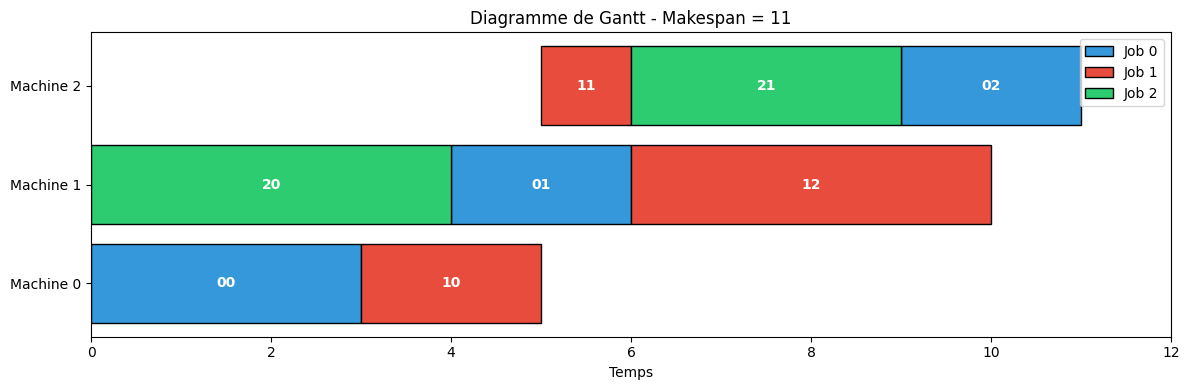

In [6]:
if ORTOOLS_OK and (status == cp_model.OPTIMAL or status == cp_model.FEASIBLE):
    # Affichage du schedule
    print("\n" + "=" * 60)
    print("SCHEDULE OPTIMAL")
    print("=" * 60)
    
    for job_name, operations in JOBS_DATA.items():
        print(f"\n{job_name}:")
        for task_id, (machine, duration) in enumerate(operations):
            start = solver.Value(all_tasks[(job_name, task_id)][0])
            end = solver.Value(all_tasks[(job_name, task_id)][1])
            print(f"  Op {task_id}: Machine {machine}, [{start}, {end}] (duree={duration})")
    
    # Visualisation en diagramme de Gantt
    fig, ax = plt.subplots(figsize=(12, 4))
    
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    job_colors = {job_name: colors[i % len(colors)] 
                  for i, job_name in enumerate(JOBS_DATA.keys())}
    
    for job_name, operations in JOBS_DATA.items():
        for task_id, (machine, duration) in enumerate(operations):
            start = solver.Value(all_tasks[(job_name, task_id)][0])
            ax.barh(f'Machine {machine}', duration, left=start, 
                   color=job_colors[job_name], edgecolor='black',
                   label=f'{job_name}' if task_id == 0 else '')
            # Annotation
            ax.text(start + duration/2, f'Machine {machine}', 
                   f'{job_name[-1]}{task_id}', ha='center', va='center',
                   fontsize=10, fontweight='bold', color='white')
    
    ax.set_xlabel('Temps')
    ax.set_title(f'Diagramme de Gantt - Makespan = {solver.Value(makespan)}')
    ax.legend(loc='upper right')
    ax.set_xlim(0, solver.Value(makespan) + 1)
    plt.tight_layout()
    plt.show()

### Interpretation du Job Shop Schedule

**Sortie obtenue** : Un diagramme de Gantt montrant l'assignation des operations aux machines.

| Job | Operations | Contraintes de precedence |
|-----|------------|---------------------------|
| Job 0 | 3 operations | Op0 -> Op1 -> Op2 |
| Job 1 | 3 operations | Op0 -> Op1 -> Op2 |
| Job 2 | 2 operations | Op0 -> Op1 |

**Points cles** :
1. Les contraintes **NoOverlap** assurent qu'une machine traite une operation a la fois
2. Les contraintes de **precedence** assurent l'ordre des operations dans un job
3. Le solveur optimise le **makespan** (temps total de completion)

> **Comparaison avec PDDL** : Ce probleme pourrait etre modelise en PDDL, mais CP-SAT est plus naturel et souvent plus efficace pour les problemes d'ordonnancement purs.

---

## 4. Vehicle Routing Problem (VRP)

Le **Vehicle Routing Problem** est un probleme classique de logistique : determiner les routes optimales d'une flotte de vehicules pour livrer des clients a partir d'un depot.

### 4.1 Definition du probleme

**Donnees** :
- Un depot (position 0)
- $n$ clients (positions 1 a $n$)
- $k$ vehicules avec capacite $C$
- Matrice de distances $d_{ij}$
- Demandes $q_i$ pour chaque client

**Objectif** : Minimiser la distance totale parcourue par tous les vehicules

**Contraintes** :
- Chaque client est visite exactement une fois
- La capacite de chaque vehicule est respectee
- Chaque route commence et finit au depot

In [7]:
# OR-Tools a un module dedie au VRP
if ORTOOLS_OK:
    from ortools.constraint_solver import routing_enums_pb2
    from ortools.constraint_solver import pywrapcp
    
    # Donnees du probleme VRP
    # Positions: depot + 4 clients
    # Depot est a l'index 0
    
    def create_distance_matrix():
        """Cree une matrice de distances symetrique."""
        # Distances entre depot (0) et 4 clients (1-4)
        # Index: 0=Depot, 1=ClientA, 2=ClientB, 3=ClientC, 4=ClientD
        return [
            [0, 10, 15, 20, 25],   # Depuis depot
            [10, 0, 12, 18, 22],   # Depuis ClientA
            [15, 12, 0, 8, 16],    # Depuis ClientB
            [20, 18, 8, 0, 14],    # Depuis ClientC
            [25, 22, 16, 14, 0],   # Depuis ClientD
        ]
    
    def create_demand_vector():
        """Demande de chaque client (depot = 0)."""
        return [0, 3, 4, 2, 5]  # Depot, A, B, C, D
    
    # Parametres
    DISTANCE_MATRIX = create_distance_matrix()
    DEMANDS = create_demand_vector()
    NUM_VEHICLES = 2
    VEHICLE_CAPACITY = 8
    DEPOT = 0
    
    print("Probleme VRP")
    print("=" * 50)
    print(f"Clients: {len(DISTANCE_MATRIX) - 1}")
    print(f"Vehicules: {NUM_VEHICLES}")
    print(f"Capacite par vehicule: {VEHICLE_CAPACITY}")
    print(f"\nDemandes:")
    for i, d in enumerate(DEMANDS):
        if i > 0:
            print(f"  Client {i}: {d}")
    print(f"  Total demandes: {sum(DEMANDS)}")

Probleme VRP
Clients: 4
Vehicules: 2
Capacite par vehicule: 8

Demandes:
  Client 1: 3
  Client 2: 4
  Client 3: 2
  Client 4: 5
  Total demandes: 14


In [8]:
if ORTOOLS_OK:
    # Creation du Routing Index Manager
    manager = pywrapcp.RoutingIndexManager(
        len(DISTANCE_MATRIX), 
        NUM_VEHICLES, 
        DEPOT
    )
    
    # Creation du Routing Model
    routing = pywrapcp.RoutingModel(manager)
    
    # Fonction de cout (distance)
    def distance_callback(from_index, to_index):
        """Retourne la distance entre deux noeuds."""
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return DISTANCE_MATRIX[from_node][to_node]
    
    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)
    
    # Contrainte de capacite
    def demand_callback(from_index):
        """Retourne la demande du noeud."""
        from_node = manager.IndexToNode(from_index)
        return DEMANDS[from_node]
    
    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,  # null capacity slack
        [VEHICLE_CAPACITY] * NUM_VEHICLES,  # capacites des vehicules
        True,  # start cumul to zero
        'Capacity'
    )
    
    # Heuristique de recherche
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_parameters.time_limit.seconds = 5
    
    # Resolution
    print("Resolution VRP en cours...")
    solution = routing.SolveWithParameters(search_parameters)
    
    if solution:
        print(f"\nSolution trouvee !")
        print(f"Cout total (distance): {solution.ObjectiveValue()}")
        print("\nRoutes:")
        print("-" * 40)
        
        total_distance = 0
        total_load = 0
        
        for vehicle_id in range(NUM_VEHICLES):
            index = routing.Start(vehicle_id)
            plan_output = f'Vehicule {vehicle_id}: '
            route_distance = 0
            route_load = 0
            
            while not routing.IsEnd(index):
                node_index = manager.IndexToNode(index)
                route_load += DEMANDS[node_index]
                plan_output += f'{node_index} -> '
                previous_index = index
                index = solution.Value(routing.NextVar(index))
                route_distance += routing.GetArcCostForVehicle(
                    previous_index, index, vehicle_id
                )
            
            node_index = manager.IndexToNode(index)
            plan_output += f'{node_index}\n'
            plan_output += f'Distance: {route_distance}\n'
            plan_output += f'Charge: {route_load}/{VEHICLE_CAPACITY}\n'
            print(plan_output)
            
            total_distance += route_distance
            total_load += route_load
        
        print(f"\nResume:")
        print(f"  Distance totale: {total_distance}")
        print(f"  Charge totale livree: {total_load}")
    else:
        print("Pas de solution trouvee")

Resolution VRP en cours...



Solution trouvee !
Cout total (distance): 96

Routes:
----------------------------------------
Vehicule 0: 0 -> 3 -> 4 -> 0
Distance: 59
Charge: 7/8

Vehicule 1: 0 -> 1 -> 2 -> 0
Distance: 37
Charge: 7/8


Resume:
  Distance totale: 96
  Charge totale livree: 14


### Interpretation du VRP

**Sortie obtenue** : Routes optimales pour chaque vehicule avec distances et charges.

**Points cles** :
1. Le **Routing Model** d'OR-Tools est specialise pour les problemes de tournees
2. Les **dimensions** (capacite, temps, distance) permettent d'ajouter des contraintes
3. Les **metaheuristiques** (Guided Local Search) ameliorent les solutions

> **Lien avec la planification** : Le VRP peut etre vu comme un probleme de planification ou les "actions" sont les deplacements de vehicules, mais l'approche CP est plus naturelle.

---

## 5. Planning as SAT/CP

Il est possible d'encoder un probleme de planification PDDL en SAT ou CP. Cette approche, appelee **planning-as-SAT**, peut etre tres efficace.

### 5.1 Encodage sequentiel

L'idee est de creer des variables pour chaque fait a chaque pas de temps :

$$x_{p,t} = 1 \Leftrightarrow \text{le fait } p \text{ est vrai au temps } t$$

$$a_{a,t} = 1 \Leftrightarrow \text{l'action } a \text{ est executee au temps } t$$

**Contraintes** :
1. **Initial** : $x_{p,0} = 1$ pour les faits initiaux
2. **But** : $x_{g,T} = 1$ pour les buts (a l'horizon T)
3. **Preconditions** : $a_{a,t} \Rightarrow \bigwedge_{p \in pre(a)} x_{p,t}$
4. **Effets** : $a_{a,t} \Rightarrow \bigwedge_{e \in add(a)} x_{e,t+1} \land \bigwedge_{e \in del(a)} \neg x_{e,t+1}$
5. **Frame axioms** : Les faits non modifies persistent

In [9]:
# Exemple simplifie : Planning as CP pour Blocks World (version tres simple)
# Nous modelisons un mini-probleme : deplacer 1 bloc A de la table vers B

if ORTOOLS_OK:
    # Probleme simplifie :
    # - 2 blocs : A, B
    # - Actions possibles : pick-up(x), put-down(x), stack(x,y), unstack(x,y)
    # - Etat initial : A et B sur la table
    # - But : A sur B
    
    model = cp_model.CpModel()
    
    HORIZON = 4  # Nombre max d'etapes
    BLOCKS = ['A', 'B']
    
    # Variables d'etat (pour chaque bloc a chaque temps)
    # on_table[b,t] = 1 si le bloc b est sur la table au temps t
    # on_A_B[t] = 1 si A est sur B au temps t
    # holding_A[t] = 1 si on tient A au temps t
    # handempty[t] = 1 si la main est vide au temps t
    
    on_table = {}
    for b in BLOCKS:
        for t in range(HORIZON + 1):
            on_table[(b, t)] = model.NewBoolVar(f'on_table_{b}_{t}')
    
    on_A_B = {t: model.NewBoolVar(f'on_A_B_{t}') for t in range(HORIZON + 1)}
    holding_A = {t: model.NewBoolVar(f'holding_A_{t}') for t in range(HORIZON + 1)}
    handempty = {t: model.NewBoolVar(f'handempty_{t}') for t in range(HORIZON + 1)}
    clear = {(b, t): model.NewBoolVar(f'clear_{b}_{t}') 
             for b in BLOCKS for t in range(HORIZON + 1)}
    
    # Etat initial
    model.Add(on_table[('A', 0)] == 1)
    model.Add(on_table[('B', 0)] == 1)
    model.Add(handempty[0] == 1)
    model.Add(clear[('A', 0)] == 1)
    model.Add(clear[('B', 0)] == 1)
    
    # But : A sur B
    model.Add(on_A_B[HORIZON] == 1)
    
    # Contraintes de coherence (simplifiees)
    for t in range(HORIZON):
        # Un bloc ne peut pas etre sur la table ET sur un autre
        model.Add(on_table[('A', t + 1)] + on_A_B[t + 1] + holding_A[t + 1] == 1)
        model.Add(on_table[('B', t + 1)] + holding_A[t + 1] <= 1)  # B ne peut pas etre tenu si A sur B
        
        # Si A est sur B au temps t+1, alors B n'est pas clear au temps t+1
        # (simplification - logique complete plus complexe)
    
    # Objectif : atteindre le but le plus tot possible
    # Minimiser le temps ou le but est atteint
    goal_time = model.NewIntVar(0, HORIZON, 'goal_time')
    for t in range(HORIZON + 1):
        # Si le but est atteint au temps t, goal_time <= t
        model.Add(goal_time <= t).OnlyEnforceIf(on_A_B[t])
    model.Minimize(goal_time)
    
    # Resolution
    solver = cp_model.CpSolver()
    status = solver.Solve(model)
    
    print("Planning as CP - Blocks World simplifie")
    print("=" * 50)
    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        print(f"Statut: {'OPTIMAL' if status == cp_model.OPTIMAL else 'FEASIBLE'}")
        print(f"But atteint au temps: {solver.Value(goal_time)}")
        print("\nEvolution des etats:")
        for t in range(HORIZON + 1):
            on_A = "Table" if solver.Value(on_table[('A', t)]) else ("B" if solver.Value(on_A_B[t]) else "Hand")
            on_B = "Table" if solver.Value(on_table[('B', t)]) else "Other"
            hand = "Empty" if solver.Value(handempty[t]) else "Holding A"
            print(f"  t={t}: A on {on_A}, B on {on_B}, Hand: {hand}")
    else:
        print(f"Pas de solution (statut: {status})")
        print("Note: Le modele simplifie peut necessiter plus d'etapes ou etre incomplet")

Planning as CP - Blocks World simplifie
Statut: OPTIMAL
But atteint au temps: 0

Evolution des etats:
  t=0: A on Table, B on Table, Hand: Empty
  t=1: A on Table, B on Other, Hand: Holding A
  t=2: A on Table, B on Other, Hand: Holding A
  t=3: A on Table, B on Other, Hand: Holding A
  t=4: A on B, B on Other, Hand: Holding A


### Interpretation du Planning as CP

**Sortie obtenue** : Une sequence d'etats atteignant le but.

**Observations** :
1. L'encodage direct est **complexe** (frame axioms, contraintes d'exclusion mutuelle)
2. Le nombre de variables explose avec l'horizon et le nombre de faits
3. Pour la planification, les solveurs PDDL specialises sont generalement plus efficaces

> **Note** : Cette approche est utile quand on veut combiner planification avec d'autres contraintes (temps, ressources) difficiles a exprimer en PDDL pur.

---

## 6. Comparaison CP vs PDDL

Cette section resume les differences et guide le choix entre CP et PDDL.

In [10]:
# Tableau comparatif detaille
comparison = {
    'Aspect': [
        'Paradigme',
        'Variables',
        'Contraintes',
        'Objectif',
        'Solution',
        'Problemes types',
        'Optimalite',
        'Scalabilite',
        'Expressivite',
        'Courbe apprentissage',
        'Outils',
    ],
    'PDDL (Planification)': [
        'Recherche dans espace d\'etats',
        'Predicats (faits booleens)',
        'Preconditions/effets des actions',
        'Minimiser longueur du plan',
        'Sequence d\'actions',
        'Blocks World, Logistics, Gripper',
        'Admissible (A* + LM-cut)',
        'Bonne avec heuristiques',
        'Actions, temps, objets',
        'Moyenne (syntaxe PDDL)',
        'Fast Downward, ENHSP',
    ],
    'CP (Contraintes)': [
        'Propagation + Recherche',
        'Entieres, booleennes, intervalles',
        'Lineaires, globales (AllDiff, etc.)',
        'Optimiser fonction objectif',
        'Affectation de variables',
        'Scheduling, VRP, Sudoku',
        'Exacte (CP-SAT)',
        'Tres bonne (propagation)',
        'Contraintes, ressources, temps',
        'Moyenne (API Python)',
        'OR-Tools, Gecode, Choco',
    ],
}

print("Comparaison CP vs PDDL")
print("=" * 80)
print(f"{'Aspect':<25} | {'PDDL':<25} | {'CP':<25}")
print("-" * 80)
for i in range(len(comparison['Aspect'])):
    print(f"{comparison['Aspect'][i]:<25} | {comparison['PDDL (Planification)'][i]:<25} | {comparison['CP (Contraintes)'][i]:<25}")
print("=" * 80)

Comparaison CP vs PDDL
Aspect                    | PDDL                      | CP                       
--------------------------------------------------------------------------------
Paradigme                 | Recherche dans espace d'etats | Propagation + Recherche  
Variables                 | Predicats (faits booleens) | Entieres, booleennes, intervalles
Contraintes               | Preconditions/effets des actions | Lineaires, globales (AllDiff, etc.)
Objectif                  | Minimiser longueur du plan | Optimiser fonction objectif
Solution                  | Sequence d'actions        | Affectation de variables 
Problemes types           | Blocks World, Logistics, Gripper | Scheduling, VRP, Sudoku  
Optimalite                | Admissible (A* + LM-cut)  | Exacte (CP-SAT)          
Scalabilite               | Bonne avec heuristiques   | Tres bonne (propagation) 
Expressivite              | Actions, temps, objets    | Contraintes, ressources, temps
Courbe apprentissage      | Moy

In [11]:
# Guide de decision
decision_guide = """
GUIDE DE DECISION : PDDL ou CP ?
==================================

CHOISIR PDDL si :
------------------
1. Le probleme implique un AGENT qui EXECUTE des ACTIONS
2. Les actions ont des PRECONDITIONS et EFFETS clairs
3. On cherche une SEQUENCE d'actions (un plan)
4. Le domaine peut etre decrit avec des PREDICATS logiques
5. L'ordre des actions est crucial

Exemples typiques :
- Robot qui manipule des objets (Blocks World)
- Logistique avec chargement/dechargement
- Jeux avec coups autorises


CHOISIR CP (OR-Tools) si :
-------------------------
1. Le probleme est essentiellement COMBINATOIRE
2. On OPTIMISE une fonction objectif (temps, cout)
3. Les CONTRAINTES sont plus naturelles que les actions
4. Le probleme est STATIQUE (pas de sequence d'actions)
5. On a des RESSOURCES limitees (machines, vehicules)

Exemples typiques :
- Ordonnancement (Job Shop, Project Scheduling)
- Tournees de vehicules (VRP)
- Affectation (Sudoku, planning personnel)
- Decoupe, bin packing


HYBRIDE si :
-----------
1. Planification avec contraintes de ressources complexes
2. Planification temporelle (PDDL 2.1 + contraintes)
3. Utiliser unified-planning avec backend CP
"""

print(decision_guide)


GUIDE DE DECISION : PDDL ou CP ?

CHOISIR PDDL si :
------------------
1. Le probleme implique un AGENT qui EXECUTE des ACTIONS
2. Les actions ont des PRECONDITIONS et EFFETS clairs
3. On cherche une SEQUENCE d'actions (un plan)
4. Le domaine peut etre decrit avec des PREDICATS logiques
5. L'ordre des actions est crucial

Exemples typiques :
- Robot qui manipule des objets (Blocks World)
- Logistique avec chargement/dechargement
- Jeux avec coups autorises


CHOISIR CP (OR-Tools) si :
-------------------------
1. Le probleme est essentiellement COMBINATOIRE
2. On OPTIMISE une fonction objectif (temps, cout)
3. Les CONTRAINTES sont plus naturelles que les actions
4. Le probleme est STATIQUE (pas de sequence d'actions)
5. On a des RESSOURCES limitees (machines, vehicules)

Exemples typiques :
- Ordonnancement (Job Shop, Project Scheduling)
- Tournees de vehicules (VRP)
- Affectation (Sudoku, planning personnel)
- Decoupe, bin packing


HYBRIDE si :
-----------
1. Planification avec cont

---

## 7. Resume et points cles

### 7.1 Concepts appris

| Concept | Description |
|---------|-------------|
| **CP-SAT** | Solveur de contraintes Google OR-Tools |
| **Variables d'intervalle** | Modeles avec debut, duree, fin |
| **NoOverlap** | Contrainte de non-chevauchement |
| **Makespan** | Temps total de completion |
| **Routing Model** | API specialisee pour le VRP |
| **Planning-as-SAT** | Encodage de planification en SAT/CP |

### 7.2 Points cles a retenir

1. **CP vs PDDL** : Deux paradigmes complementaires
   - PDDL pour les sequences d'actions avec preconditions/effets
   - CP pour l'optimisation combinatoire avec contraintes

2. **OR-Tools CP-SAT** est excellent pour :
   - Scheduling (Job Shop, Project)
   - Routing (VRP, TSP)
   - Problemes d'affectation

3. **Choisir le bon outil** :
   - Si le probleme est "que faire ?" -> PDDL
   - Si le probleme est "comment optimiser ?" -> CP

4. **Integration possible** :
   - unified-planning peut utiliser des solveurs CP
   - Les deux approches peuvent etre combinees

### 7.3 Prochaines etapes

Dans le notebook **Planners-8-Temporal**, nous explorerons :
- PDDL 2.1 avec durees et parallellisme
- Planification temporelle
- Integration avec les contraintes de temps

---

## Ressources

- [OR-Tools Documentation](https://developers.google.com/optimization)
- [CP-SAT Primer](https://github.com/google/or-tools/blob/stable/ortools/sat/docs/README.md)
- [Job Shop Scheduling Example](https://developers.google.com/optimization/scheduling/job_shop)
- [VRP Documentation](https://developers.google.com/optimization/routing)

---

**Notebook suivant** : [Planners-8-Temporal](Planners-8-Temporal.ipynb)

## Exercice : Optimisation d'un Emploi du Temps

Concevez un solveur CP-SAT pour un probleme d'ordonnancement realiste.

### Objectifs
1. Modeliser un probleme d'emploi du temps universitaire
2. Utiliser les contraintes NoOverlap et Cumulative
3. Optimiser selon plusieurs criteres
4. Comparer avec une approche PDDL

### Instructions


### Questions d'analyse
- Pourquoi CP-SAT est-il plus adapte que PDDL pour ce probleme ?
- Comment gereriez-vous des contraintes additionnelles (preferences profs) ?
- Quelle est la complexite theorique de ce probleme ?

In [ ]:
# TODO: Definisir les donnees du probleme
# Cours, salles, professeurs, creneaux horaires

cours = {
    'Math': {'duree': 2, 'prof': 'A', 'eleves': 30},
    'Physique': {'duree': 2, 'prof': 'B', 'eleves': 25},
    'Info': {'duree': 3, 'prof': 'A', 'eleves': 20},
    'Chimie': {'duree': 2, 'prof': 'C', 'eleves': 25},
}

salles = {
    'S1': {'capacite': 30},
    'S2': {'capacite': 40},
}

creneaux = list(range(8, 18))  # 8h-18h

# TODO: Creez le modele CP-SAT
# - Variables: start[cours], room[cours]
# - Contraintes: 
#   - Un prof ne peut pas enseigner deux cours en meme temps
#   - Une salle ne peut pas accueillir deux cours en meme temps
#   - Capacite salle >= nb eleves
# - Objectif: Minimiser les trous dans l'emploi du temps

# TODO: Resoudre et afficher l'emploi du temps optimal
